# Experimental EMD Images

Load every EMD file with pyTEMlib, print the acquisition details, normalize the HAADF image, and plot the complete dataset.

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyTEMlib.file_tools as ft

root_path = Path.cwd().resolve()
if not (root_path / 'experimental_data').is_dir():
    root_path = root_path.parent

files = sorted((root_path / 'experimental_data').glob('*.emd'))
if not files:
    raise FileNotFoundError('No EMD files found in experimental_data')

print(f'Found {len(files)} EMD files')

Found 4 EMD files


In [28]:
images = []
for path in files:
    dset = ft.open_file(str(path))
    for key in dset.keys():
        if dset[key].title == 'HAADF':

            haadf = dset[key]
            pixel_size_nm = float(haadf.original_metadata['BinaryResult']['PixelSize']['width']) * 1e9
            frame_time = float(haadf.original_metadata['Scan']['FrameTime'])

            haadf -= haadf.min()
            haadf /= haadf.max()
            images.append((path, haadf, pixel_size_nm, frame_time))

            print(
                f'{path.name}: {haadf.shape[1]} x {haadf.shape[0]} px, '
                f'{pixel_size_nm:.5f} nm/px, frame time {frame_time:.5f} s'
            )

QuasiCrystal.emd: 2048 x 2048 px, 0.00751 nm/px, frame time 45.19937 s
TwinBoundary.emd: 1024 x 1024 px, 0.00801 nm/px, frame time 22.58944 s
TwinsOverview.emd: 2048 x 2048 px, 0.01601 nm/px, frame time 87.81824 s
WS2.emd: 1024 x 1024 px, 0.01062 nm/px, frame time 22.58944 s


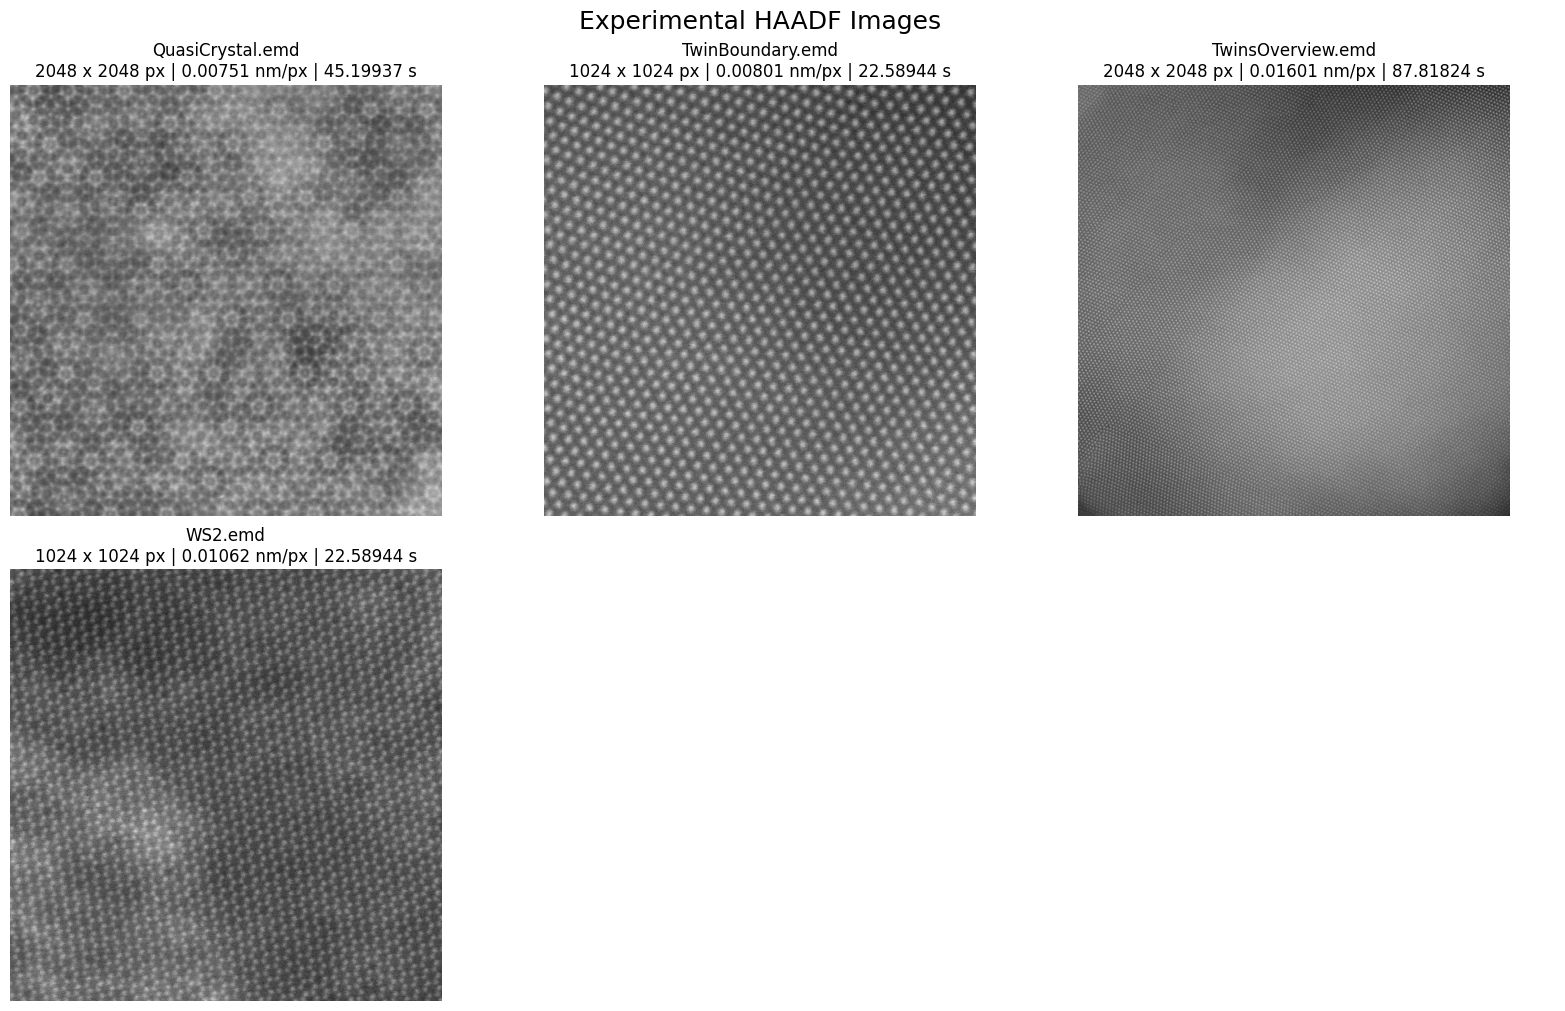

In [29]:
columns = 3
rows = int(np.ceil(len(images) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(16, 5 * rows), squeeze=False, constrained_layout=True)

for axis, (path, haadf, pixel_size_nm, frame_time) in zip(axes.flat, images):
    axis.imshow(np.asarray(haadf), cmap='gray', vmin=0.0, vmax=1.0)
    axis.set_title(
        f'{path.name}\n'
        f'{haadf.shape[1]} x {haadf.shape[0]} px | '
        f'{pixel_size_nm:.5f} nm/px | {frame_time:.5f} s'
    )
    axis.axis('off')

for axis in axes.flat[len(images):]:
    axis.axis('off')

fig.suptitle('Experimental HAADF Images', fontsize=18)
plt.show()


In [30]:
from scipy.ndimage import gaussian_filter

dog_sigma_small = 1.0
dog_sigma_large = 20.0
dog_images = []

for path, haadf, pixel_size_nm, frame_time in images:
    image = np.asarray(haadf, dtype=np.float32)
    dog = gaussian_filter(image, dog_sigma_small) - gaussian_filter(image, dog_sigma_large)
    low, high = np.percentile(dog, [1.0, 99.8])
    dog = np.clip((dog - low) / max(high - low, 1e-8), 0.0, 1.0)
    dog_images.append((path, dog, pixel_size_nm, frame_time))

print(f'DoG background subtraction: sigma={dog_sigma_small} px - sigma={dog_sigma_large} px')


DoG background subtraction: sigma=1.0 px - sigma=20.0 px


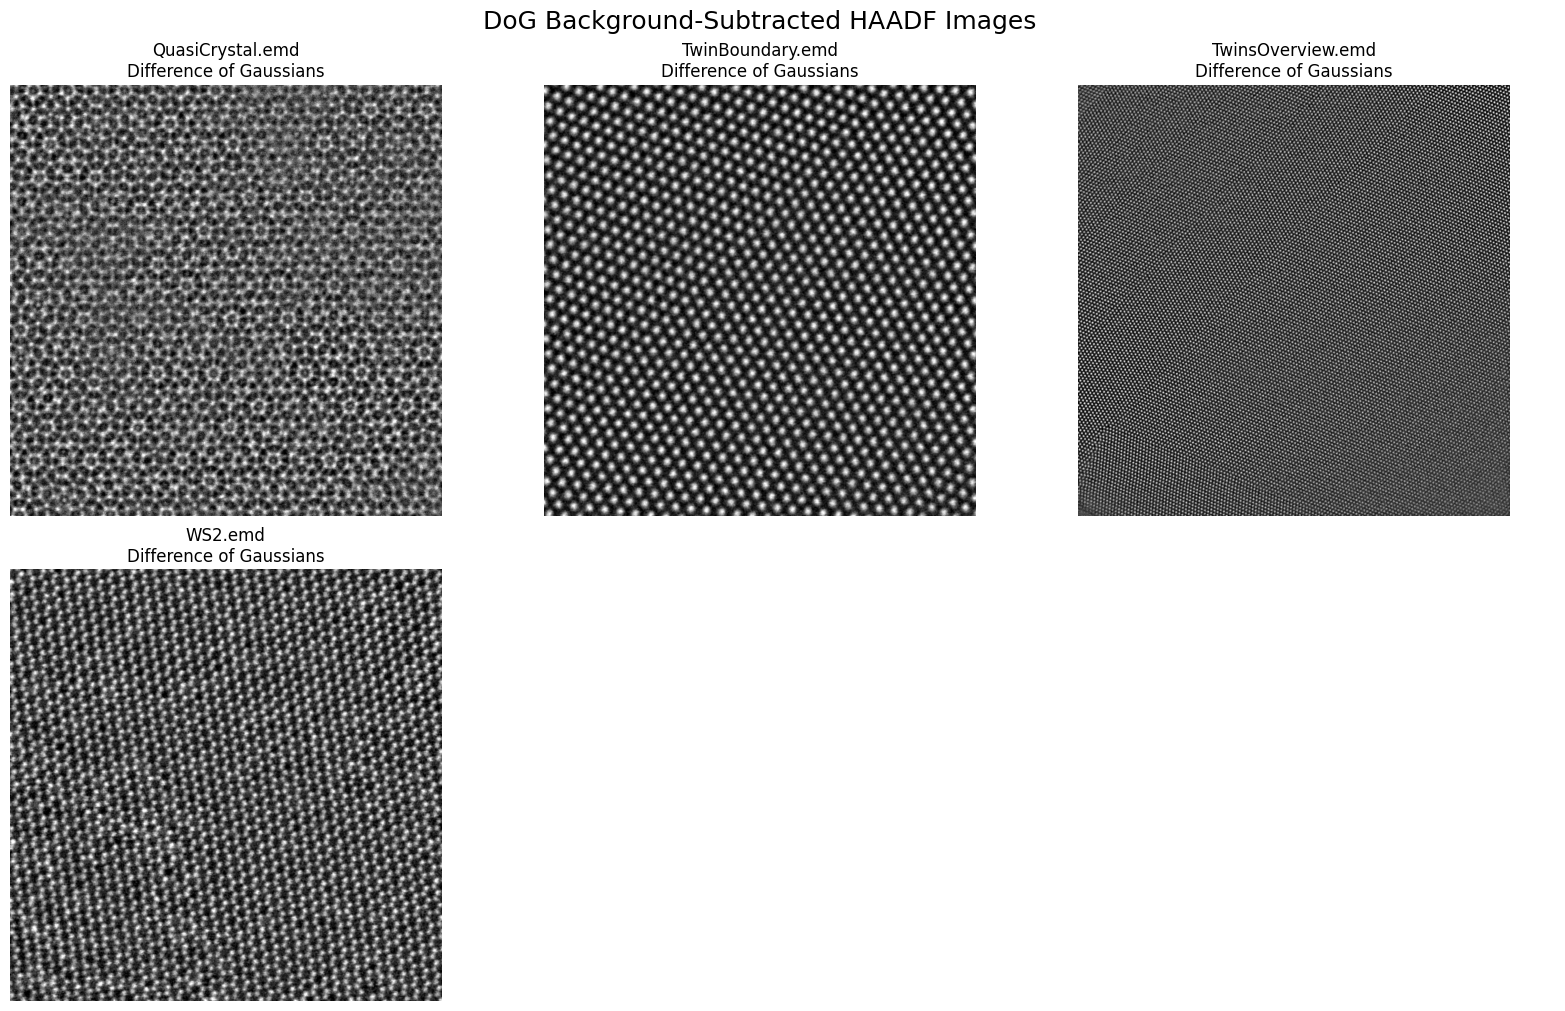

In [31]:
columns = 3
rows = int(np.ceil(len(dog_images) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(16, 5 * rows), squeeze=False, constrained_layout=True)

for axis, (path, dog, pixel_size_nm, frame_time) in zip(axes.flat, dog_images):
    axis.imshow(dog, cmap='gray', vmin=0.0, vmax=1.0)
    axis.set_title(f'{path.name}\nDifference of Gaussians')
    axis.axis('off')

for axis in axes.flat[len(dog_images):]:
    axis.axis('off')

fig.suptitle('DoG Background-Subtracted HAADF Images', fontsize=18)
plt.show()
